<left>
    <img src="https://weclouddata.s3.amazonaws.com/images/logos/wcd_logo_new_2.png" width='20%'>
</left>

<h1 align="left"> Demo: Monitoring Agent Performance </h1>
<center align="left"> <font size='4'>  Developed by: </font><font size='4' color='#33AAFBD'>WeCloudData</font></center>
<br>

**Purpose:**  
Demonstrate how to **measure and monitor the runtime performance** of a LangGraph-based agent system — capturing response times, profiling tool-usage patterns, and analysing system behaviour across many runs to surface regressions and bottlenecks.

**Scenario:** E-Commerce Shopping Assistant  
A LangGraph agent that helps customers search products, check inventory, apply discount codes, and generate order summaries — while a metrics layer silently records every performance signal for analysis.

**Key Topics Covered:**
- Measuring per-step and end-to-end response times
- Tracking tool usage frequency, latency, and error rates
- Analysing system behaviour across multiple simulated runs
- Building a performance dashboard with statistical summaries and charts

---


## 1. Setup

In [ ]:
# Run this cell first
!pip install -q langchain langchain-openai langgraph matplotlib pandas --quiet

import os
from getpass import getpass

if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ")

print("Setup complete")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 5.2 MB/s eta 0:00:00
Enter your OpenAI API key: ··········
Setup complete


In [ ]:
import time, uuid, json, random, statistics
from datetime import datetime, timedelta
from typing import Annotated, TypedDict, Dict, List, Optional, Any, Tuple
from collections import defaultdict
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec

from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, ToolMessage
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
print("All libraries imported")


All libraries imported


## 2. Performance Metrics Infrastructure

The metrics layer is built from three components:

| Class | Role |
|---|---|
| `RunRecord` | Immutable snapshot of one complete agent run |
| `ToolMetric` | Accumulated statistics for a single tool (calls, latency, errors) |
| `PerformanceMonitor` | Central collector — records runs, aggregates stats, renders reports |

This mirrors the **RED method** used in production SREs:
- **R**ate — how many requests per second?
- **E**rrors — what fraction fail?
- **D**uration — how long do they take?


In [ ]:
@dataclass
class RunRecord:
    """One completed agent invocation."""
    run_id:        str
    query:         str
    category:      str          # search | inventory | discount | order | multi
    total_ms:      float
    llm_calls:     int
    tool_calls:    List[Dict]   # [{name, latency_ms, success}]
    total_tokens:  int
    status:        str          # success | error
    final_answer:  str


@dataclass
class ToolMetric:
    """Aggregated stats for one tool."""
    name:         str
    call_count:   int             = 0
    error_count:  int             = 0
    latencies_ms: List[float]     = field(default_factory=list)

    @property
    def success_rate(self)  -> float:
        return (self.call_count - self.error_count) / max(self.call_count, 1)

    @property
    def avg_latency_ms(self) -> float:
        return statistics.mean(self.latencies_ms) if self.latencies_ms else 0.0

    @property
    def p95_latency_ms(self) -> float:
        if not self.latencies_ms: return 0.0
        s = sorted(self.latencies_ms)
        return s[max(0, int(len(s) * 0.95) - 1)]


class PerformanceMonitor:
    """Central store for all performance data."""

    def __init__(self):
        self.runs:         List[RunRecord]       = []
        self.tool_metrics: Dict[str, ToolMetric] = {}

    def record(self, record: RunRecord):
        self.runs.append(record)
        for tc in record.tool_calls:
            tm = self.tool_metrics.setdefault(tc["name"], ToolMetric(name=tc["name"]))
            tm.call_count  += 1
            tm.latencies_ms.append(tc["latency_ms"])
            if not tc["success"]:
                tm.error_count += 1

    def to_dataframe(self) -> pd.DataFrame:
        return pd.DataFrame([{
            "run_id":       r.run_id,
            "category":     r.category,
            "total_ms":     r.total_ms,
            "llm_calls":    r.llm_calls,
            "tool_calls":   len(r.tool_calls),
            "total_tokens": r.total_tokens,
            "status":       r.status,
        } for r in self.runs])

    def print_summary(self):
        df = self.to_dataframe()
        all_ms = [r.total_ms for r in self.runs]
        SEP = "=" * 65
        print(f"\n{SEP}")
        print(" PERFORMANCE SUMMARY")
        print(SEP)
        print(f"  Total runs         : {len(self.runs)}")
        sr = (df['status']=='success').mean()*100
        print(f"  Success rate       : {sr:.1f}%")
        print(f"  Avg response time  : {statistics.mean(all_ms):.0f} ms")
        print(f"  P95 response time  : {sorted(all_ms)[max(0,int(len(all_ms)*.95)-1)]:.0f} ms")
        print(f"  Total tokens       : {df['total_tokens'].sum():,}")
        print(f"  Est. cost          : ${df['total_tokens'].sum()/1e6*0.15:.4f}")
        print()
        print(f"  {'Category':12s} {'Runs':5s} {'Succ%':7s} {'AvgMs':8s} {'AvgTools':9s}")
        print(f"  {'-'*45}")
        for cat, grp in df.groupby("category"):
            sc = (grp['status']=='success').mean()*100
            print(f"  {cat:12s} {len(grp):5d}  {sc:5.1f}%  {grp['total_ms'].mean():8.0f}  {grp['tool_calls'].mean():9.1f}")
        print(SEP)
        print()
        print(f"  {'Tool':28s} {'Calls':6s} {'Err%':7s} {'AvgMs':8s} {'P95Ms':8s}")
        print(f"  {'-'*55}")
        for tm in sorted(self.tool_metrics.values(), key=lambda x: -x.call_count):
            ep = (1-tm.success_rate)*100
            print(f"  {tm.name:28s} {tm.call_count:6d}  {ep:5.1f}%  {tm.avg_latency_ms:8.1f}  {tm.p95_latency_ms:8.1f}")
        print(f"{SEP}\n")


monitor = PerformanceMonitor()
print("PerformanceMonitor ready")


PerformanceMonitor ready


## 3. E-Commerce Tools (with Injected Latency Simulation)

Four tools simulate a realistic e-commerce backend.  
Each tool has **configurable simulated network latency** so we can observe how tool latency affects overall agent performance — a common production concern.

| Tool | Simulated Latency | Occasional Error? |
|---|---|---|
| `search_products` | 80–150 ms | No |
| `check_inventory` | 40–90 ms | Yes (5% transient failures) |
| `apply_discount_code` | 60–120 ms | Yes (invalid codes rejected) |
| `generate_order_summary` | 30–60 ms | No |


In [ ]:
CATALOGUE = {
    "laptop":     {"name": "ProBook Laptop 15",  "price": 1199.99, "brand": "TechEdge"},
    "headphones": {"name": "SoundWave Pro ANC",  "price": 249.99,  "brand": "AudioMax"},
    "keyboard":   {"name": "MechaType TKL",      "price": 129.99,  "brand": "KeyCraft"},
    "monitor":    {"name": "ClearView 27 4K",    "price": 549.99,  "brand": "VisualPlus"},
    "mouse":      {"name": "PrecisionClick X3",  "price": 79.99,   "brand": "KeyCraft"},
    "webcam":     {"name": "StreamCam HD 4K",    "price": 189.99,  "brand": "VisualPlus"},
    "chair":      {"name": "ErgoSeat Pro",       "price": 699.99,  "brand": "ComfortDesk"},
    "desk":       {"name": "StandUp Pro Desk",   "price": 899.99,  "brand": "ComfortDesk"},
}
INVENTORY     = {k: random.randint(0, 30) for k in CATALOGUE}
DISCOUNT_CODES = {"SAVE10": 0.10, "WCD20": 0.20, "TECH15": 0.15}

@tool
def search_products(query: str) -> str:
    """Search the product catalogue. Returns matching products with price and brand."""
    time.sleep(random.uniform(0.08, 0.15))
    q = query.lower()
    matches = [
        f"• {v['name']} | ${v['price']:.2f} | Brand: {v['brand']} | SKU: {k.upper()}"
        for k, v in CATALOGUE.items()
        if q in k or q in v["name"].lower() or q in v["brand"].lower()
    ]
    return "Search results:\n" + "\n".join(matches) if matches else f"No products found for '{query}'."

@tool
def check_inventory(sku: str) -> str:
    """Check current stock level for a product SKU."""
    time.sleep(random.uniform(0.04, 0.09))
    if random.random() < 0.05:
        raise RuntimeError("Inventory service temporarily unavailable (503)")
    sku = sku.lower()
    if sku not in INVENTORY:
        return f"SKU '{sku.upper()}' not recognised."
    qty = INVENTORY[sku]
    status = "In Stock" if qty > 5 else ("Low Stock ⚠" if qty > 0 else "Out of Stock ✗")
    return f"{sku.upper()}: {qty} units — {status}"

@tool
def apply_discount_code(code: str, original_price: float) -> str:
    """Apply a discount code to a price and return the discounted amount."""
    time.sleep(random.uniform(0.06, 0.12))
    code = code.upper().strip()
    if code not in DISCOUNT_CODES:
        return f"Code '{code}' is invalid or expired."
    pct = DISCOUNT_CODES[code]
    saving = original_price * pct
    return (f"Code {code} applied: {pct*100:.0f}% off | "
            f"Original: ${original_price:.2f} | Saving: ${saving:.2f} | "
            f"New total: ${original_price - saving:.2f}")

@tool
def generate_order_summary(items: str, total_price: float) -> str:
    """Generate a formatted order confirmation summary."""
    time.sleep(random.uniform(0.03, 0.06))
    order_id = f"ORD-{random.randint(100000,999999)}"
    eta = (datetime.now() + timedelta(days=random.randint(2,5))).strftime("%A %d %b %Y")
    return (f"Order Confirmed! | Order ID: {order_id} | "
            f"Items: {items} | Total: ${total_price:.2f} | ETA: {eta}")

tools = [search_products, check_inventory, apply_discount_code, generate_order_summary]
print(f"{len(tools)} instrumented tools ready")


4 instrumented tools ready


## 4. LangGraph Agent with Performance Hooks

Performance hooks are injected at two points in the graph:
- **`agent_node`** — measures LLM call duration and counts tokens
- **`monitored_tool_node`** — wraps `ToolNode` to time each invocation and flag errors

```
START → [agent_node] ──(tool calls?)──► [monitored_tool_node] ─► [agent_node]
                     ──(no tools)────► END
```


In [ ]:
# Mutable run-level context reset per invocation
_ctx: Dict[str, Any] = {}

def reset_ctx():
    _ctx.update({"run_id": str(uuid.uuid4())[:8], "llm_calls": 0,
                 "tool_calls": [], "total_tokens": 0})

# State
class ShopState(TypedDict):
    messages: Annotated[list, add_messages]

llm_with_tools = llm.bind_tools(tools)

def agent_node(state: ShopState) -> ShopState:
    response = llm_with_tools.invoke(state["messages"])
    _ctx["llm_calls"] += 1
    usage = getattr(response, "usage_metadata", None)
    if usage:
        _ctx["total_tokens"] += usage.get("total_tokens", 0)
    return {"messages": [response]}

base_tool_node = ToolNode(tools)

def monitored_tool_node(state: ShopState) -> ShopState:
    last_msg = state["messages"][-1]
    pending  = getattr(last_msg, "tool_calls", []) or []
    t0 = time.perf_counter()
    try:
        result  = base_tool_node.invoke(state)
        success = True
    except Exception:
        result  = {"messages": state["messages"]}
        success = False
    elapsed = (time.perf_counter() - t0) * 1000
    per_ms  = elapsed / max(len(pending), 1)
    for tc in pending:
        ok = success
        for msg in result.get("messages", []):
            if isinstance(msg, ToolMessage) and msg.tool_call_id == tc.get("id"):
                if "unavailable" in msg.content.lower() or msg.content.startswith("Error"):
                    ok = False
        _ctx["tool_calls"].append({"name": tc["name"], "latency_ms": per_ms, "success": ok})
    return result

def should_continue(state: ShopState) -> str:
    last = state["messages"][-1]
    return "tools" if getattr(last, "tool_calls", None) else END

graph = StateGraph(ShopState)
graph.add_node("agent", agent_node)
graph.add_node("tools", monitored_tool_node)
graph.set_entry_point("agent")
graph.add_conditional_edges("agent", should_continue, {"tools": "tools", END: END})
graph.add_edge("tools", "agent")
agent = graph.compile()

print("LangGraph agent compiled")


LangGraph agent compiled


## 5. Helper — `run_agent`

In [ ]:
CATEGORY_KEYWORDS = {
    "search":    ["search","find","show","list","what","any"],
    "inventory": ["stock","inventory","available","units","how many"],
    "discount":  ["discount","code","coupon","promo","saving","off"],
    "order":     ["order","buy","purchase","confirm","summary"],
}

def classify(q: str) -> str:
    ql = q.lower()
    for cat, kws in CATEGORY_KEYWORDS.items():
        if any(k in ql for k in kws):
            return cat
    return "multi"

def run_agent(query: str, verbose: bool = True) -> RunRecord:
    """Run one query, record performance metrics, return a RunRecord."""
    reset_ctx()
    cat = classify(query)
    t0  = time.perf_counter()
    try:
        out    = agent.invoke({"messages": [HumanMessage(content=query)]})
        answer = out["messages"][-1].content
        status = "success"
    except Exception as e:
        answer, status = f"Error: {e}", "error"
    ms = (time.perf_counter() - t0) * 1000

    record = RunRecord(
        run_id=_ctx["run_id"], query=query, category=cat,
        total_ms=ms, llm_calls=_ctx["llm_calls"],
        tool_calls=list(_ctx["tool_calls"]),
        total_tokens=_ctx["total_tokens"],
        status=status, final_answer=answer,
    )
    monitor.record(record)
    if verbose:
        ok = "✅" if status == "success" else "❌"
        print(f"  {ok} [{record.run_id}] {ms:6.0f}ms | "
              f"{len(record.tool_calls)} tools | {cat:10s} | {query[:55]}")
    return record

print("run_agent helper ready")


run_agent helper ready


## 6. Demo — Warm-Up Runs (One per Category)

Run four representative queries — one per category — so you can see **live output** before the batch simulation.


In [ ]:
print("\nWarm-up queries...\n")

r1 = run_agent("Search for all mechanical keyboards and show me the options.")
r2 = run_agent("Check the inventory for LAPTOP and MONITOR SKUs.")
r3 = run_agent("Apply discount code WCD20 to a purchase of $549.99.")
r4 = run_agent(
    "Search for a webcam, check WEBCAM inventory, apply code SAVE10 to $189.99, "
    "then generate an order summary at the discounted price."
)

print("\n--- Final answer (multi-step run) ---")
print(r4.final_answer[:350])



Warm-up queries...

  ✅ [3170b6b3]   3205ms | 1 tools | search     | Search for all mechanical keyboards and show me the opt
  ✅ [43a6a7cd]   3420ms | 2 tools | inventory  | Check the inventory for LAPTOP and MONITOR SKUs.
  ✅ [80b42146]   2215ms | 1 tools | discount   | Apply discount code WCD20 to a purchase of $549.99.
  ✅ [1081fce6]   5006ms | 4 tools | search     | Search for a webcam, check WEBCAM inventory, apply code

--- Final answer (multi-step run) ---
Here's the summary of your order:

- **Item**: StreamCam HD 4K
- **Original Price**: $189.99
- **Discount Applied**: SAVE10 (10% off)
- **Discounted Price**: $170.99
- **Stock Level**: 11 units available
- **Order ID**: ORD-403434
- **Estimated Delivery**: Tuesday, 28 Apr 2026

Your order has been confirmed!


## 7. Batch Simulation — 20 Benchmark Queries

Run **20 diverse queries** across all categories.  
This is the foundation for all statistical analysis below.

> ⏱ Expect ~2–3 minutes (real LLM calls). Set `verbose=False` to suppress per-run output.


In [ ]:
BENCHMARK = [
    # search (5)
    "Find all products from the brand KeyCraft.",
    "Show me all chairs and desks available.",
    "Search for headphones and list their prices.",
    "What audio equipment do you have?",
    "Find all VisualPlus products.",
    # inventory (4)
    "How many units of the LAPTOP SKU are in stock?",
    "Check inventory levels for CHAIR and DESK.",
    "Is the MOUSE SKU available? How many units?",
    "Check stock for KEYBOARD and MONITOR.",
    # discount (3)
    "Apply code TECH15 to a monitor costing $549.99.",
    "What saving do I get with SAVE10 on a $699.99 chair?",
    "Try promo code INVALID99 on a $249.99 purchase.",
    # order (3)
    "Generate an order summary for MechaType TKL at $129.99.",
    "Create a purchase confirmation for ErgoSeat Pro at $629.99.",
    "Confirm my order for PrecisionClick X3 at $71.99.",
    # multi (5)
    "Search for keyboards, check KEYBOARD inventory, apply WCD20 to $129.99.",
    "Find all VisualPlus products, check MONITOR inventory, generate order for $549.99.",
    "Search for a chair, check CHAIR stock, apply SAVE10 to $699.99, confirm order.",
    "Look up webcams, verify WEBCAM stock, generate an order summary for $189.99.",
    "Find the cheapest product, apply TECH15, then confirm the order.",
]

print(f"Running {len(BENCHMARK)} benchmark queries...\n")
for i, q in enumerate(BENCHMARK, 1):
    print(f"[{i:02d}/{len(BENCHMARK)}]", end=" ")
    run_agent(q, verbose=True)

print(f"\nBatch complete — {len(monitor.runs)} total runs recorded")


Running 20 benchmark queries...

[01/20]   ✅ [35980a63]   2814ms | 1 tools | search     | Find all products from the brand KeyCraft.
[02/20]   ✅ [dbac67ea]   3825ms | 2 tools | search     | Show me all chairs and desks available.
[03/20]   ✅ [b380d1b2]   2058ms | 1 tools | search     | Search for headphones and list their prices.
[04/20]   ✅ [75c5a2bd]   1901ms | 1 tools | search     | What audio equipment do you have?
[05/20]   ✅ [3a908383]   3185ms | 1 tools | search     | Find all VisualPlus products.
[06/20]   ✅ [2760e566]   1483ms | 1 tools | search     | How many units of the LAPTOP SKU are in stock?
[07/20]   ✅ [3971f0de]   2361ms | 2 tools | inventory  | Check inventory levels for CHAIR and DESK.
[08/20]   ❌ [6dbf7e2a]   1252ms | 1 tools | search     | Is the MOUSE SKU available? How many units?
[09/20]   ✅ [03032d4d]   2161ms | 2 tools | inventory  | Check stock for KEYBOARD and MONITOR.
[10/20]   ✅ [801f53af]   2117ms | 1 tools | discount   | Apply code TECH15 to a monitor co

## 8. Measuring Response Time

We examine response time from three angles:
1. **Run-order timeline** — spot slow outliers as they occur
2. **Distribution histogram** — understand the spread (is it bimodal?)
3. **Box plots by category** — which query types are inherently slower?


/tmp/ipykernel_13626/1224400129.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_c.boxplot(cat_data, labels=cat_order, patch_artist=True,


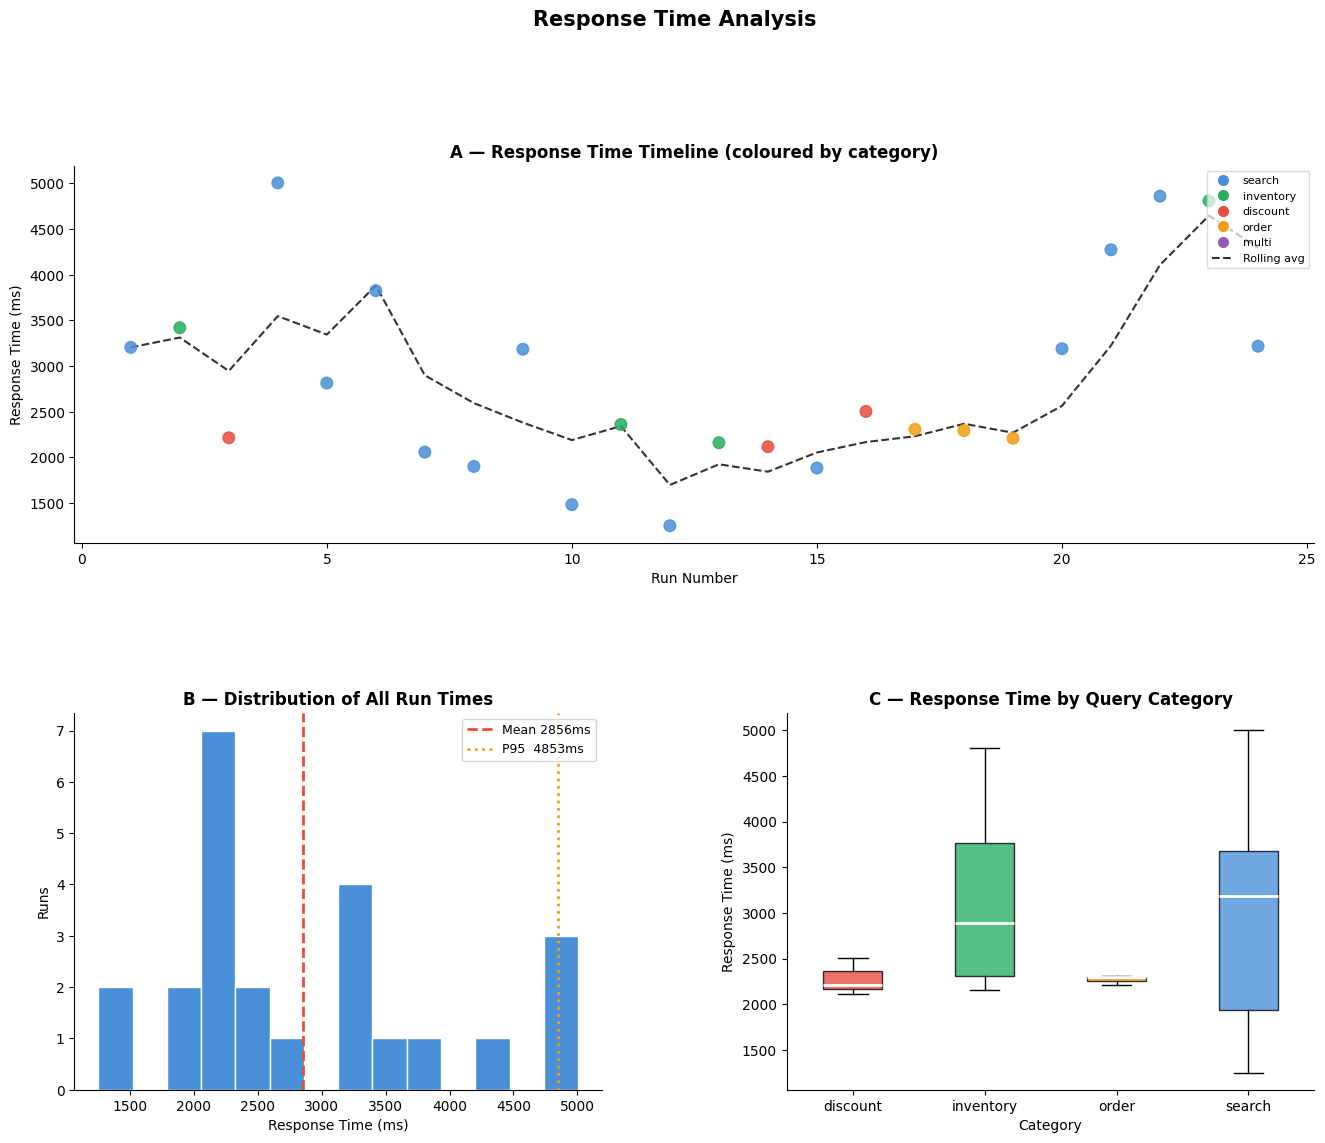

Figure 1 (Response Time) saved


In [ ]:
df = monitor.to_dataframe()

fig = plt.figure(figsize=(16, 12))
gs  = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

COLOUR_MAP = {"search": "#4A90D9", "inventory": "#27AE60",
              "discount": "#E74C3C", "order": "#F39C12", "multi": "#9B59B6"}

# Panel A: run-order timeline
ax_a = fig.add_subplot(gs[0, :])  # full top row
colours = [COLOUR_MAP.get(c, "#888") for c in df["category"]]
ax_a.scatter(range(1, len(df)+1), df["total_ms"], c=colours, s=70, zorder=3, alpha=0.85)
roll = pd.Series(df["total_ms"].values).rolling(3, min_periods=1).mean()
ax_a.plot(range(1, len(df)+1), roll, color="#333", lw=1.5, ls="--",
          label="3-run rolling avg")
from matplotlib.lines import Line2D
handles = [Line2D([0],[0],marker="o",color="w",markerfacecolor=c,markersize=9,label=k)
           for k,c in COLOUR_MAP.items()]
handles.append(Line2D([0],[0],color="#333",lw=1.5,ls="--",label="Rolling avg"))
ax_a.legend(handles=handles, loc="upper right", fontsize=8, framealpha=0.7)
ax_a.set_xlabel("Run Number"); ax_a.set_ylabel("Response Time (ms)")
ax_a.set_title("A — Response Time Timeline (coloured by category)", fontweight="bold")
ax_a.spines["top"].set_visible(False); ax_a.spines["right"].set_visible(False)

# Panel B: histogram
ax_b = fig.add_subplot(gs[1, 0])
ax_b.hist(df["total_ms"], bins=14, color="#4A90D9", edgecolor="white", lw=0.8)
mean_ms = df["total_ms"].mean()
p95_ms  = df["total_ms"].quantile(0.95)
ax_b.axvline(mean_ms, color="#E74C3C", lw=2, ls="--", label=f"Mean {mean_ms:.0f}ms")
ax_b.axvline(p95_ms,  color="#F39C12", lw=2, ls=":",  label=f"P95  {p95_ms:.0f}ms")
ax_b.set_xlabel("Response Time (ms)"); ax_b.set_ylabel("Runs")
ax_b.set_title("B — Distribution of All Run Times", fontweight="bold")
ax_b.legend(fontsize=9)
ax_b.spines["top"].set_visible(False); ax_b.spines["right"].set_visible(False)

#  Panel C: box plots by category
ax_c = fig.add_subplot(gs[1, 1])
cat_order = sorted(df["category"].unique())
cat_data  = [df[df["category"]==c]["total_ms"].values for c in cat_order]
bp = ax_c.boxplot(cat_data, labels=cat_order, patch_artist=True,
                  medianprops=dict(color="white", lw=2))
for patch, cat in zip(bp["boxes"], cat_order):
    patch.set_facecolor(COLOUR_MAP.get(cat, "#888"))
    patch.set_alpha(0.78)
ax_c.set_xlabel("Category"); ax_c.set_ylabel("Response Time (ms)")
ax_c.set_title("C — Response Time by Query Category", fontweight="bold")
ax_c.spines["top"].set_visible(False); ax_c.spines["right"].set_visible(False)

fig.suptitle("Response Time Analysis", fontsize=15, fontweight="bold", y=1.01)
plt.savefig("/tmp/fig_response.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure 1 (Response Time) saved")


In [ ]:
#  Percentile table
lats = sorted(df["total_ms"])
print("\nResponse-Time Percentile Table (all runs):")
print(f"  {'Percentile':12s}  {'Latency (ms)':>14s}")
print("  " + "-"*28)
for pct in [50, 75, 90, 95, 99, 100]:
    idx = max(0, int(len(lats) * pct / 100) - 1)
    print(f"  P{pct:<11d}  {lats[idx]:>14.0f}")



Response-Time Percentile Table (all runs):
  Percentile      Latency (ms)
  ----------------------------
  P50                     2361
  P75                     3218
  P90                     4273
  P95                     4810
  P99                     4860
  P100                    5006


## 9. Tracking Tool Usage

Understanding which tools are called most, how long they take, and how often they fail is critical for:
- **Capacity planning** — do we need to scale the inventory service?
- **Reliability engineering** — which tool has the highest error rate?
- **Cost attribution** — which workflow drives the most tokens?


In [ ]:
monitor.print_summary()



 PERFORMANCE SUMMARY
  Total runs         : 24
  Success rate       : 95.8%
  Avg response time  : 2856 ms
  P95 response time  : 4810 ms
  Total tokens       : 12,338
  Est. cost          : $0.0019

  Category     Runs  Succ%   AvgMs    AvgTools 
  ---------------------------------------------
  discount         3  100.0%      2278        1.0
  inventory        4  100.0%      3188        2.2
  order            3  100.0%      2270        1.0
  search          14   92.9%      3011        1.9

  Tool                         Calls  Err%    AvgMs    P95Ms   
  -------------------------------------------------------
  search_products                  14    0.0%      84.7     138.8
  check_inventory                  13    7.7%      48.2      65.2
  apply_discount_code               7    0.0%      71.1     108.7
  generate_order_summary            7    0.0%      50.9      57.7



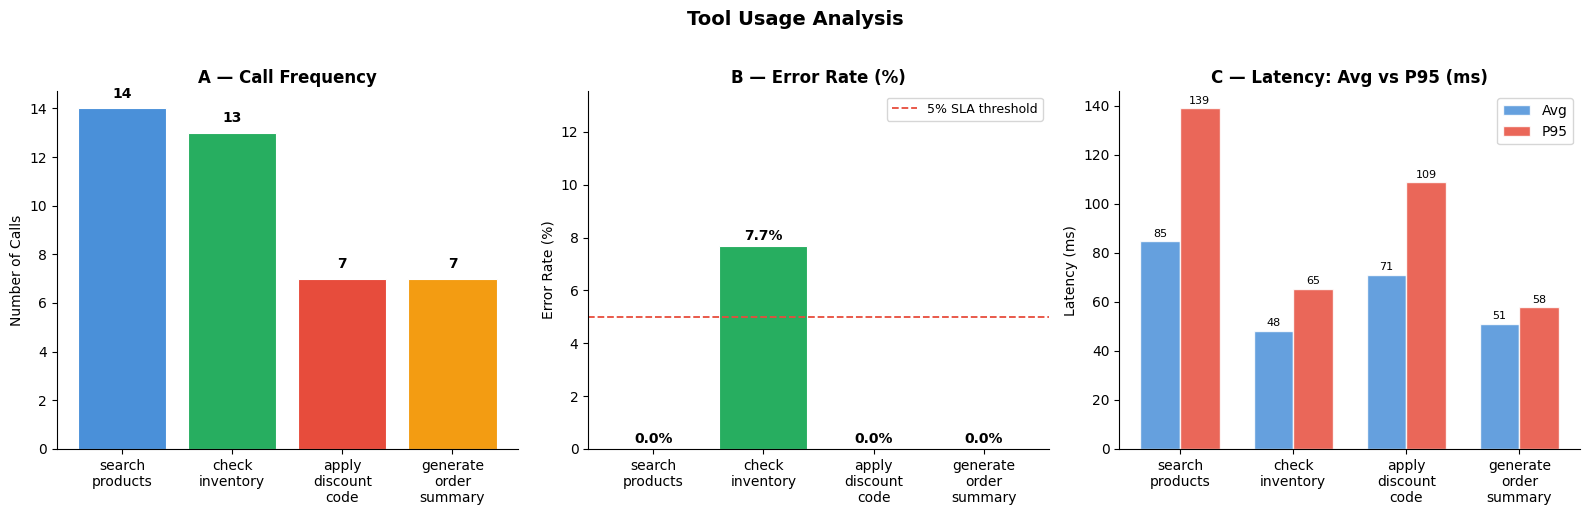

Figure 2 (Tool Usage) saved


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Tool Usage Analysis", fontsize=14, fontweight="bold", y=1.02)

tms        = list(monitor.tool_metrics.values())
short_names = [t.name.replace("_","\n") for t in tms]
bar_cols   = ["#4A90D9","#27AE60","#E74C3C","#F39C12"]

# Panel A — call frequency
ax = axes[0]
bars = ax.bar(short_names, [t.call_count for t in tms],
              color=bar_cols, edgecolor="white", lw=0.8)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
            str(int(b.get_height())), ha="center", va="bottom",
            fontsize=10, fontweight="bold")
ax.set_title("A — Call Frequency", fontweight="bold")
ax.set_ylabel("Number of Calls")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

# Panel B — error rate
ax2 = axes[1]
error_rates = [(1-t.success_rate)*100 for t in tms]
bars2 = ax2.bar(short_names, error_rates, color=bar_cols, edgecolor="white", lw=0.8)
for b, v in zip(bars2, error_rates):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+0.1,
             f"{v:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax2.axhline(5, color="#E74C3C", lw=1.3, ls="--", label="5% SLA threshold")
ax2.set_title("B — Error Rate (%)", fontweight="bold")
ax2.set_ylabel("Error Rate (%)")
ax2.set_ylim(0, max(error_rates)*1.5+2)
ax2.legend(fontsize=9)
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)

# Panel C — avg vs P95 latency
ax3 = axes[2]
x = range(len(tms)); w = 0.35
b_avg = ax3.bar([i-w/2 for i in x], [t.avg_latency_ms for t in tms],
                w, label="Avg", color="#4A90D9", alpha=0.85, edgecolor="white")
b_p95 = ax3.bar([i+w/2 for i in x], [t.p95_latency_ms for t in tms],
                w, label="P95", color="#E74C3C", alpha=0.85, edgecolor="white")
for b in list(b_avg)+list(b_p95):
    ax3.text(b.get_x()+b.get_width()/2, b.get_height()+1,
             f"{b.get_height():.0f}", ha="center", va="bottom", fontsize=8)
ax3.set_xticks(list(x)); ax3.set_xticklabels(short_names)
ax3.set_title("C — Latency: Avg vs P95 (ms)", fontweight="bold")
ax3.set_ylabel("Latency (ms)")
ax3.legend()
ax3.spines["top"].set_visible(False); ax3.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("/tmp/fig_tools.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure 2 (Tool Usage) saved")


## 10. Analysing System Behaviour Over Multiple Runs

With 24+ data points we can now answer **behavioural questions** invisible from a single run:

- Do multi-step queries take proportionally longer, or does the LLM amortise the overhead?
- Is there a correlation between token usage and response time?
- Which categories have the highest success rates?
- How are tool calls distributed across runs?


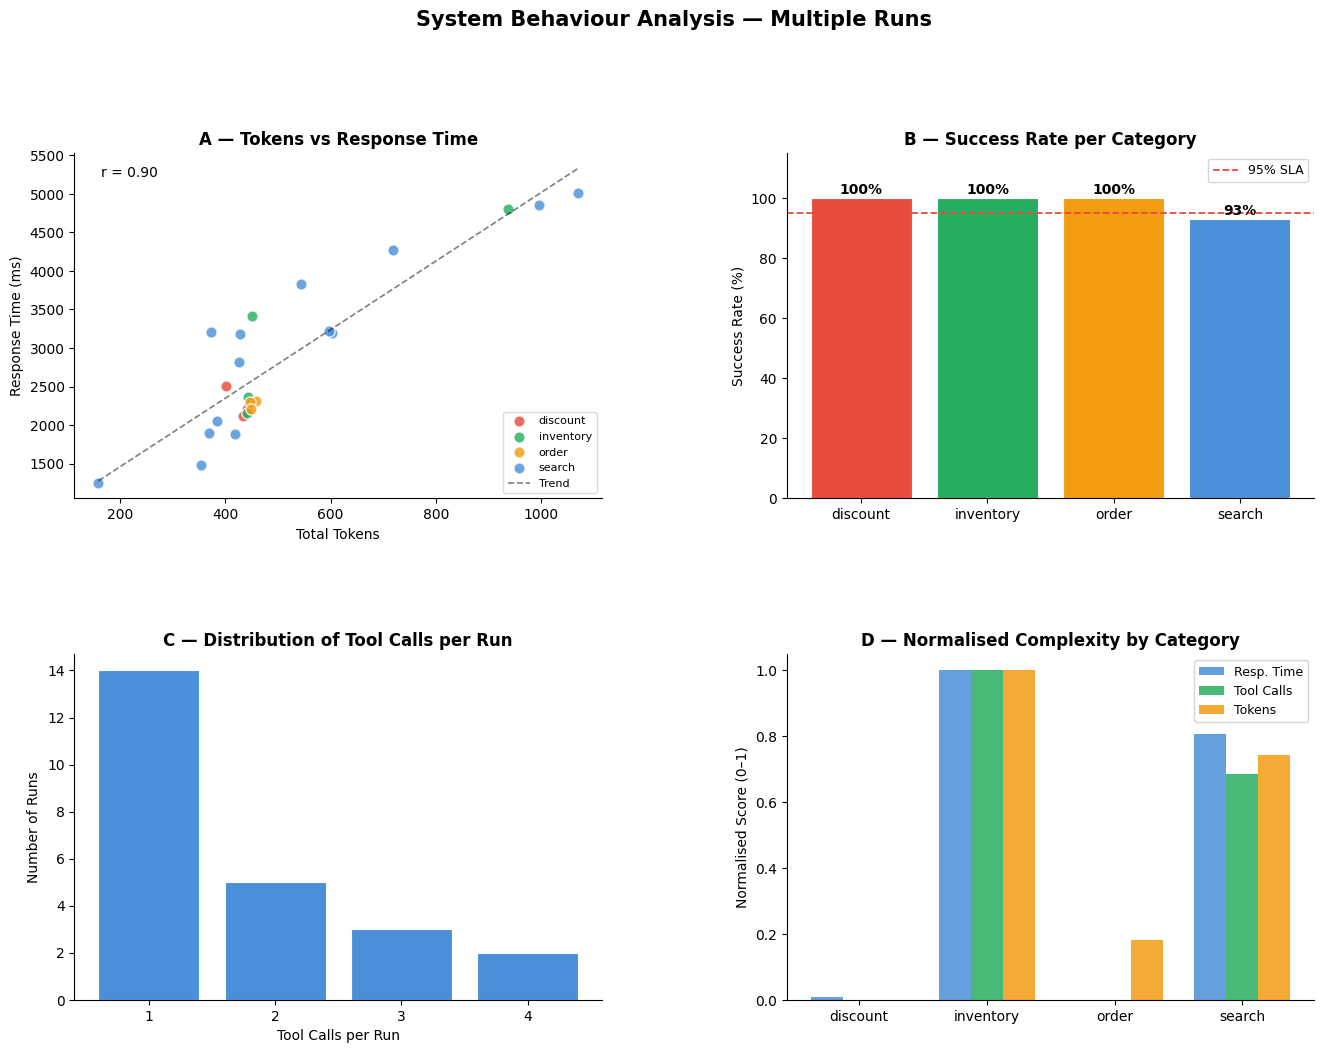

Figure 3 (System Behaviour) saved


In [ ]:
fig = plt.figure(figsize=(16, 11))
gs  = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

#  Panel A: tokens vs response time scatter
ax_a = fig.add_subplot(gs[0, 0])
for cat, grp in df.groupby("category"):
    ax_a.scatter(grp["total_tokens"], grp["total_ms"],
                 c=COLOUR_MAP.get(cat,"#888"), label=cat, s=65, alpha=0.82, edgecolors="white")
corr = df["total_tokens"].fillna(0).corr(df["total_ms"])
z = np.polyfit(df["total_tokens"].fillna(0), df["total_ms"], 1)
xs = sorted(df["total_tokens"].fillna(0))
ax_a.plot(xs, np.poly1d(z)(xs), "k--", lw=1.2, alpha=0.5, label="Trend")
ax_a.text(0.05, 0.93, f"r = {corr:.2f}", transform=ax_a.transAxes, fontsize=10)
ax_a.set_xlabel("Total Tokens"); ax_a.set_ylabel("Response Time (ms)")
ax_a.set_title("A — Tokens vs Response Time", fontweight="bold")
ax_a.legend(fontsize=8, framealpha=0.7)
ax_a.spines["top"].set_visible(False); ax_a.spines["right"].set_visible(False)

# ── Panel B: success rate per category ────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
sr_df = df.groupby("category")["status"].apply(lambda s: (s=="success").mean()*100)
bc    = [COLOUR_MAP.get(c,"#888") for c in sr_df.index]
bars  = ax_b.bar(sr_df.index, sr_df.values, color=bc, edgecolor="white", lw=0.8)
for b, v in zip(bars, sr_df.values):
    ax_b.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
              f"{v:.0f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax_b.axhline(95, color="#E74C3C", ls="--", lw=1.3, label="95% SLA")
ax_b.set_ylim(0, 115); ax_b.legend(fontsize=9)
ax_b.set_title("B — Success Rate per Category", fontweight="bold")
ax_b.set_ylabel("Success Rate (%)")
ax_b.spines["top"].set_visible(False); ax_b.spines["right"].set_visible(False)

#  Panel C: tool calls per run histogram
ax_c = fig.add_subplot(gs[1, 0])
tc_counts = df["tool_calls"].value_counts().sort_index()
ax_c.bar(tc_counts.index, tc_counts.values, color="#4A90D9", edgecolor="white", lw=0.8)
ax_c.set_xlabel("Tool Calls per Run"); ax_c.set_ylabel("Number of Runs")
ax_c.set_title("C — Distribution of Tool Calls per Run", fontweight="bold")
ax_c.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax_c.spines["top"].set_visible(False); ax_c.spines["right"].set_visible(False)

#  Panel D: avg metrics per category (horizontal bars)
ax_d = fig.add_subplot(gs[1, 1])
cat_summary = df.groupby("category")[["total_ms","tool_calls","total_tokens"]].mean()
norm = (cat_summary - cat_summary.min()) / (cat_summary.max() - cat_summary.min() + 1e-9)
x_pos = np.arange(len(cat_summary))
bar_w = 0.25
ax_d.bar(x_pos - bar_w, norm["total_ms"],     bar_w, label="Resp. Time",  color="#4A90D9", alpha=0.85)
ax_d.bar(x_pos,         norm["tool_calls"],   bar_w, label="Tool Calls",  color="#27AE60", alpha=0.85)
ax_d.bar(x_pos + bar_w, norm["total_tokens"], bar_w, label="Tokens",      color="#F39C12", alpha=0.85)
ax_d.set_xticks(x_pos); ax_d.set_xticklabels(cat_summary.index)
ax_d.set_ylabel("Normalised Score (0–1)")
ax_d.set_title("D — Normalised Complexity by Category", fontweight="bold")
ax_d.legend(fontsize=9)
ax_d.spines["top"].set_visible(False); ax_d.spines["right"].set_visible(False)

fig.suptitle("System Behaviour Analysis — Multiple Runs", fontsize=15,
             fontweight="bold", y=1.01)
plt.savefig("/tmp/fig_behaviour.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure 3 (System Behaviour) saved")


## 11. Consolidated Performance Dashboard

Print the full statistical summary — the kind you would share in a weekly engineering review or attach to an incident post-mortem.


In [ ]:
monitor.print_summary()



 PERFORMANCE SUMMARY
  Total runs         : 24
  Success rate       : 95.8%
  Avg response time  : 2856 ms
  P95 response time  : 4810 ms
  Total tokens       : 12,338
  Est. cost          : $0.0019

  Category     Runs  Succ%   AvgMs    AvgTools 
  ---------------------------------------------
  discount         3  100.0%      2278        1.0
  inventory        4  100.0%      3188        2.2
  order            3  100.0%      2270        1.0
  search          14   92.9%      3011        1.9

  Tool                         Calls  Err%    AvgMs    P95Ms   
  -------------------------------------------------------
  search_products                  14    0.0%      84.7     138.8
  check_inventory                  13    7.7%      48.2      65.2
  apply_discount_code               7    0.0%      71.1     108.7
  generate_order_summary            7    0.0%      50.9      57.7



In [ ]:
#  Percentile SLA check
SLA_TARGETS = {50: 2000, 90: 4000, 95: 5000, 99: 8000}  # ms

lats = sorted(r.total_ms for r in monitor.runs if r.status == "success")
print("\nSLA Compliance Report:")
print(f"  {'Percentile':12s} {'Actual ms':>12s} {'SLA Target':>12s} {'Status':>8s}")
print("  " + "-"*48)
for pct, target in SLA_TARGETS.items():
    idx    = max(0, int(len(lats) * pct / 100) - 1)
    actual = lats[idx]
    status = "✅ PASS" if actual <= target else "❌ FAIL"
    print(f"  P{pct:<11d} {actual:>12.0f} {target:>12d} {status:>8s}")



SLA Compliance Report:
  Percentile      Actual ms   SLA Target   Status
  ------------------------------------------------
  P50                  2361         2000   ❌ FAIL
  P90                  4273         4000   ❌ FAIL
  P95                  4810         5000   ✅ PASS
  P99                  4860         8000   ✅ PASS


## 12. Reflection Questions

1. **Why are percentile metrics (P50, P95, P99) more informative than averages alone** for agent systems? Give a scenario where the average hides a serious problem.

2. The `check_inventory` tool has a 5% simulated failure rate. **Should the agent automatically retry on failure, or surface the error to the user?** What factors would influence your decision?

3. Looking at **Panel D (Normalised Complexity by Category)**, "multi" queries score high on all three metrics. **How would you architect a caching strategy** to reduce the load for repeated multi-step queries?

4. The SLA compliance report in Section 11 shows target thresholds. **How would you choose SLA targets for a production e-commerce agent?** Who are the stakeholders and what trade-offs exist?

5. **Token usage and response time are correlated** (Panel A). If you needed to reduce costs by 30% without increasing P95 latency, what approaches would you explore?

6. **Design an alerting rule** using only the data in `PerformanceMonitor` that would fire a PagerDuty alert when system reliability degrades — without triggering false positives on every transient error.


